In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(r"/content/transformer_health_data-1.csv")
df.head()

,Temperature,Current,Voltage,Oil_Level,Health_Condition
0,96,383,431,78,2
1,59,287,410,42,2
2,105,210,389,84,2
3,65,231,437,52,1
4,68,133,398,89,0


In [3]:
X = df[['Temperature', 'Current', 'Voltage', 'Oil_Level']]
y = df['Health_Condition']

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

In [6]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Model Accuracy: 0.96


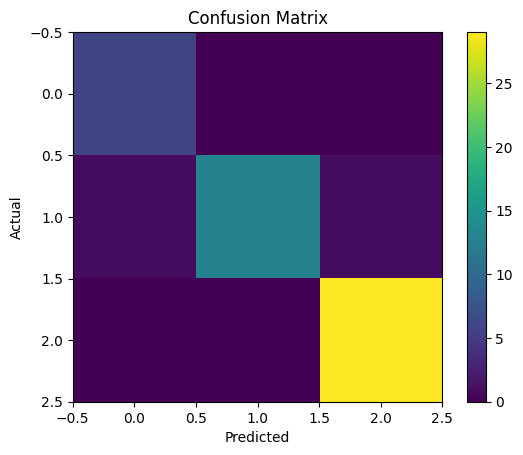

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [9]:
!pip install gradio

In [10]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def transformer_health(temp, curr, volt, oil):

    user_data = np.array([[temp, curr, volt, oil]])
    user_data_scaled = scaler.transform(user_data)

    prediction = model.predict(user_data_scaled)

    if prediction[0] == 0:
        result = "HEALTHY"
    elif prediction[0] == 1:
        result = "WARNING"
    else:
        result = "FAULTY"

    # Create plot
    plt.figure()
    plt.scatter(df['Temperature'], df['Current'], c=df['Health_Condition'])
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Load Current (A)")
    plt.title("Transformer Health Classification")
    plt.colorbar(label="Health Condition")

    return result, plt.gcf()

In [12]:
interface = gr.Interface(
    fn=transformer_health,
    inputs=[
        gr.Number(label="Transformer Temperature (°C)"),
        gr.Number(label="Load Current (A)"),
        gr.Number(label="Voltage (V)"),
        gr.Number(label="Oil Level (%)")
    ],
    outputs=[
        gr.Textbox(label="Transformer Condition"),
        gr.Plot(label="Health Classification Plot")
    ],
    title="AI Transformer Health Monitoring System",
    description="Predict transformer health using machine learning."
)

In [13]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1d0b0863541cb16a62.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
